In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
from statsmodels.tsa.arima.model import ARIMA

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [51]:
from sklearn.preprocessing import LabelEncoder

In [52]:
df = pd.read_csv("/content/Amazon sales data.csv")

df.head()

,order_id,user_id,product_id,category,price,TotaQuantity,TotalPrice,order_date.1,order_time,order_date.3,country,customer_segment,Year,Month Name,Days in Month,Week of Month,Quarter,Hour
0,100007,1239,445,Books,31.17,1,31.17,10-Dec-23,08:36:37,PM,United States,Low-Value,2023,December,31,3,4,8
1,100014,770,368,Books,6.74,1,6.74,08-Jan-22,03:55:43,AM,United States,Low-Value,2022,January,31,2,1,3
2,100016,1516,145,Books,20.04,1,20.04,28-Jan-25,12:41:06,AM,Brazil,Low-Value,2025,January,31,5,1,12
3,100021,2325,319,Books,7.07,1,7.07,15-Oct-23,07:18:00,AM,Germany,Low-Value,2023,October,31,3,4,7
4,100022,1185,477,Toys,32.12,1,32.12,06-Dec-23,05:57:08,PM,India,Low-Value,2023,December,31,2,4,5


In [53]:
df.shape

(500, 18)

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          500 non-null    int64  
 1   user_id           500 non-null    int64  
 2   product_id        500 non-null    int64  
 3   category          500 non-null    object 
 4   price             500 non-null    float64
 5   TotaQuantity      500 non-null    int64  
 6   TotalPrice        500 non-null    float64
 7   order_date.1      500 non-null    object 
 8   order_time        500 non-null    object 
 9   order_date.3      500 non-null    object 
 10  country           500 non-null    object 
 11  customer_segment  500 non-null    object 
 12  Year              500 non-null    int64  
 13  Month Name        500 non-null    object 
 14  Days in Month     500 non-null    int64  
 15  Week of Month     500 non-null    int64  
 16  Quarter           500 non-null    int64  
 1

In [55]:
df.describe()

,order_id,user_id,product_id,price,TotaQuantity,TotalPrice,Year,Days in Month,Week of Month,Quarter,Hour
count,500.000000,500.000000,500.000000,500.000000,500.00000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,100249.500000,1523.420000,241.670000,108.424800,1.58800,176.22992,2023.308000,30.420000,3.112000,2.410000,6.764000
std,144.481833,845.049606,141.859823,132.683599,1.04328,323.10029,1.035026,0.827629,1.276995,1.088241,3.357805
min,100000.000000,2.000000,3.000000,1.780000,1.00000,2.85000,2022.000000,28.000000,1.000000,1.000000,1.000000
25%,100124.750000,816.000000,117.500000,26.405000,1.00000,32.21000,2022.000000,30.000000,2.000000,1.000000,4.000000
50%,100249.500000,1510.500000,236.500000,56.030000,1.00000,80.42000,2023.000000,31.000000,3.000000,2.000000,7.000000
75%,100374.250000,2254.500000,355.250000,126.455000,2.00000,187.36500,2024.000000,31.000000,4.000000,3.000000,10.000000
max,100499.000000,3000.000000,500.000000,743.980000,5.00000,3398.30000,2025.000000,31.000000,6.000000,4.000000,12.000000


In [56]:
df.columns

Index(['order_id', 'user_id', 'product_id', 'category', 'price',
       'TotaQuantity', 'TotalPrice', 'order_date.1', 'order_time',
       'order_date.3', 'country', 'customer_segment', 'Year', 'Month Name',
       'Days in Month', 'Week of Month', 'Quarter', 'Hour'],
      dtype='object')

In [57]:
df = df.rename(columns={
    'TotaQuantity': 'quantity',
    'TotalPrice': 'revenue',
    'order_date.1': 'order_date',
    'order_date.3': 'am_pm',
    'Month Name': 'month',
    'Days in Month': 'days_in_month',
    'Week of Month': 'week_of_month'
})

In [58]:
df['order_date'] = pd.to_datetime(
    df['order_date'],
    format='%d-%b-%y'
)

In [59]:
df.isnull().sum()

,0
order_id,0
user_id,0
product_id,0
category,0
price,0
quantity,0
revenue,0
order_date,0
order_time,0
am_pm,0


In [60]:
df.duplicated().sum()

np.int64(0)

In [61]:
df['order_id'].duplicated().sum()

np.int64(0)

In [62]:
df['calculated_revenue'] = df['price'] * df['quantity']

df['revenue_difference'] = (
    df['revenue'] - df['calculated_revenue']
)

df['revenue_difference'].describe()

,revenue_difference
count,5.000000e+02
mean,3.410605e-16
std,3.255782e-14
min,-4.547474e-13
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,4.547474e-13


In [63]:
df.drop(
    columns=['calculated_revenue', 'revenue_difference'],
    inplace=True
)

In [64]:
df['month_number'] = df['order_date'].dt.month

In [65]:
df['month_name'] = df['order_date'].dt.month_name()

In [66]:
df['day'] = df['order_date'].dt.day

In [67]:
df['day_of_week'] = df['order_date'].dt.day_name()

In [68]:
df['quarter'] = df['order_date'].dt.quarter

In [69]:
df['is_weekend'] = df['order_date'].dt.dayofweek >= 5

In [70]:
total_revenue = df['revenue'].sum()
print(total_revenue)

88114.96


In [71]:
total_quantity = df['quantity'].sum()
print(total_quantity)

794


In [72]:
total_orders = df['order_id'].nunique()
print(total_orders)

500


In [73]:
category_sales = (
    df.groupby('category')['revenue']
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

category
Electronics    44844.31
Home           15270.76
Sports          9345.17
Clothing        8031.25
Beauty          3625.43
Toys            3392.67
Grocery         1918.87
Books           1686.50
Name: revenue, dtype: float64


In [74]:
segment_sales = (
    df.groupby('customer_segment')
    .agg(
        orders=('order_id','count'),
        quantity=('quantity','sum'),
        revenue=('revenue','sum')
    )
    .sort_values('revenue', ascending=False)
)

segment_sales

,orders,quantity,revenue
customer_segment,,,
High-Value,34,95,35402.63
Mid-Value,122,221,33446.77
Low-Value,344,478,19265.56


In [75]:
monthly_sales = (
    df.groupby('order_date')['revenue']
    .sum()
)

In [76]:
monthly_sales = (
    df.set_index('order_date')
      .resample('ME')['revenue']
      .sum()
)

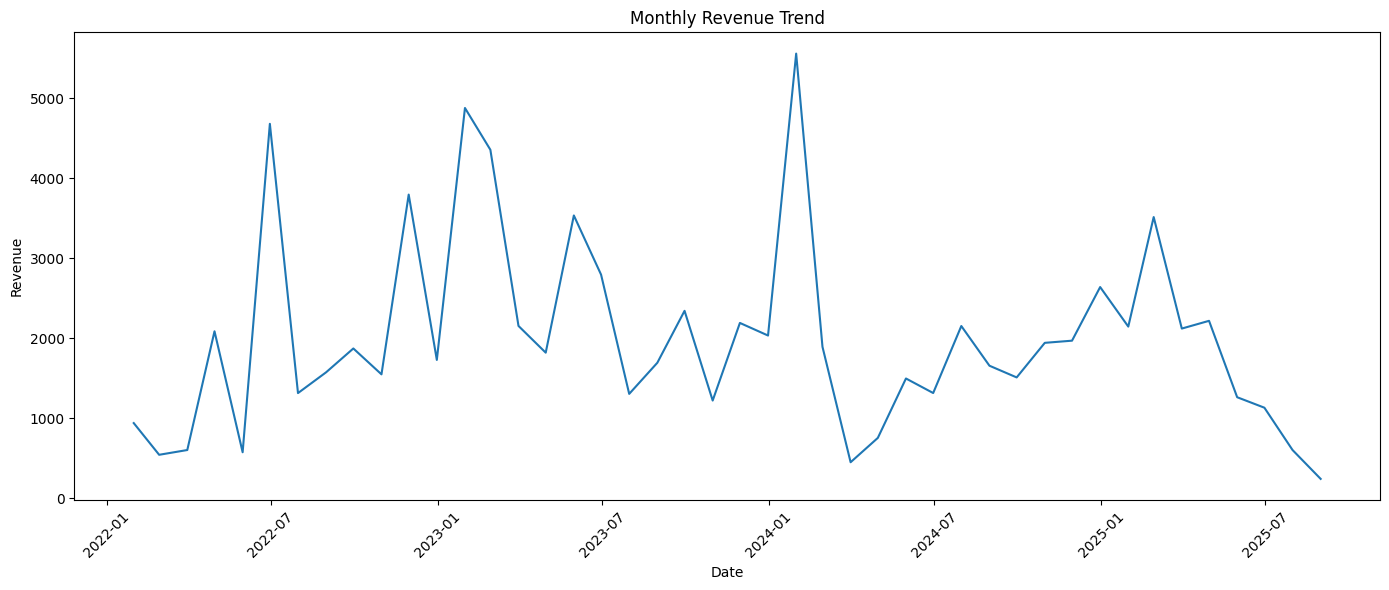

In [77]:
plt.figure(figsize=(14,6))

plt.plot(monthly_sales.index, monthly_sales.values)

plt.title('Monthly Revenue Trend')
plt.xlabel('Date')
plt.ylabel('Revenue')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [78]:
month_sales = (
    df.groupby('month_name')['revenue']
    .sum()
)

In [79]:
month_sales = (
    df.groupby('month_number')['revenue']
    .sum()
)

In [80]:
quarter_sales = (
    df.groupby('quarter')['revenue']
    .sum()
)

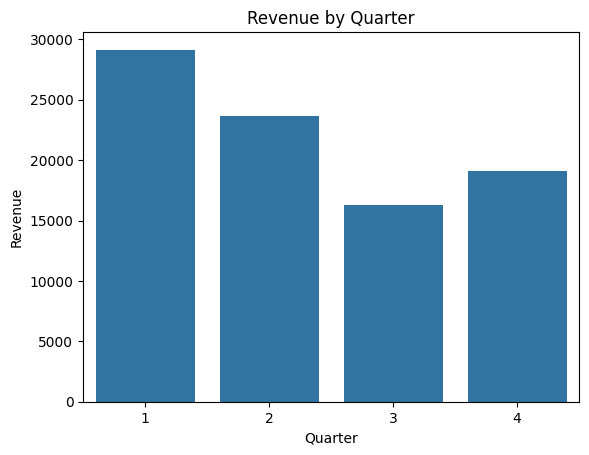

In [81]:
sns.barplot(
    x=quarter_sales.index,
    y=quarter_sales.values
)

plt.title('Revenue by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Revenue')

plt.show()

In [82]:
top_products = (
    df.groupby('product_id')
    .agg(
        orders=('order_id','count'),
        quantity=('quantity','sum'),
        revenue=('revenue','sum')
    )
    .sort_values('revenue', ascending=False)
)

top_products.head(10)

,orders,quantity,revenue
product_id,,,
364,1,5,3398.30
320,2,8,3311.01
450,3,6,3158.38
23,3,9,2048.64
170,1,5,1999.20
42,1,2,1487.96
194,2,6,1476.84
399,1,3,1449.00
447,2,4,1410.38


In [83]:
category_revenue = (
    df.groupby('category')['revenue']
    .sum()
)

category_percentage = (
    category_revenue /
    category_revenue.sum() * 100
)

category_percentage.sort_values(ascending=False)

,revenue
category,
Electronics,50.892958
Home,17.330496
Sports,10.605657
Clothing,9.114514
Beauty,4.114432
Toys,3.850277
Grocery,2.177689
Books,1.913977


In [84]:
monthly = (
    df.set_index('order_date')
      .resample('ME')
      .agg({
          'revenue':'sum',
          'quantity':'sum',
          'order_id':'count'
      })
)

In [85]:
monthly.rename(
    columns={'order_id':'orders'},
    inplace=True
)

In [86]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(
    monthly['revenue'],
    order=(1,1,1)
)

model_fit = model.fit()

forecast = model_fit.forecast(steps=6)

print(forecast)

2025-09-30    1578.100936
2025-10-31    1872.075575
2025-11-30    1936.695225
2025-12-31    1950.899509
2026-01-31    1954.021805
2026-02-28    1954.708129
Freq: ME, Name: predicted_mean, dtype: float64


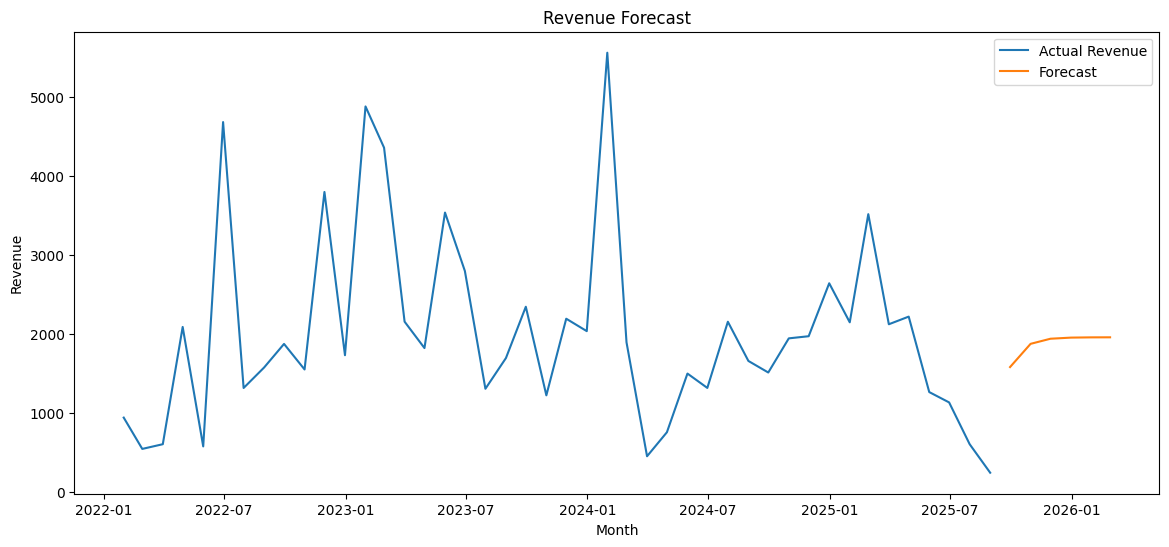

In [87]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly.index,
    monthly['revenue'],
    label='Actual Revenue'
)

future_dates = pd.date_range(
    start=monthly.index[-1] + pd.offsets.MonthEnd(1),
    periods=6,
    freq='ME'
)

plt.plot(
    future_dates,
    forecast,
    label='Forecast'
)

plt.title('Revenue Forecast')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.legend()
plt.show()